In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.ndimage.filters import gaussian_filter
from skimage.filters import window

# You need to understand the ins and outs of this code and why it applies to what problem you are trying to solve


C:\Users\conno.DESKTOP-98EBONR\AppData\Local\Temp\ipykernel_2092\3464878753.py:4: DeprecationWarning: Please import `gaussian_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter


In [353]:

"""1D, use clean signals, blurry signals and linear combinations of signals

Notes:

Clean signals - hard to get accurate phase shift due to periodicity and being able to land on the closes approximation and it being correct.
Blurry signals -
"""

phi = np.pi/3
N = 100

x = np.linspace(0, 2*np.pi, N, endpoint=False)
expected_shift = (phi / (2*np.pi)) * N

f1 = np.sin(x)
f2 = np.sin(x + phi)

# Add noise
noisy1 = f1 + 0.2*np.random.randn(N)
noisy2 = f2 + 0.2*np.random.randn(N)

# Optional: gaussian blur
noisy1 = gaussian_filter(noisy1, 1)
noisy2 = gaussian_filter(noisy2, 1)



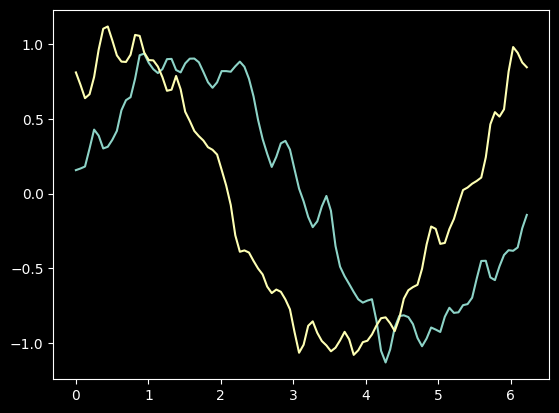

In [354]:
plt.plot(x,noisy1)
plt.plot(x, noisy2)

In [360]:
# Phase correlation
cross_corr = np.fft.ifft(np.fft.fft(noisy1) * np.conj(np.fft.fft(noisy2)))
cross_corr = np.abs(np.fft.fftshift(cross_corr))

# Compute integer shift
shift_index = np.argmax(cross_corr)
center = N // 2
shift_int = shift_index - center


In [366]:
# --- Sub-sample shift using parabolic interpolation ---
# Take the peak and its neighbors
if shift_index == 0:
    left = cross_corr[-1]
else:
    left = cross_corr[shift_index - 1]
peak = cross_corr[shift_index]
if shift_index == N - 1:
    right = cross_corr[0]
else:
    right = cross_corr[shift_index + 1]

# Parabolic interpolation formula
denom = 2*(2*peak - left - right)
if denom != 0:
    delta = 0.5 * (right - left) / denom
else:
    delta = 0

shift_subsample = shift_int + delta

In [367]:
print("Integer shift:", shift_int)
print("Sub-sample shift:", shift_subsample)
print("Expected shift:", expected_shift)

Integer shift: -34
Sub-sample shift: -33.99326747737562
Expected shift: 16.666666666666664


In [251]:
"""Side notes and facts to keep in mind when considering FFT correction versus real space correction"""



'Side notes and facts to keep in mind when considering FFT correction versus real space correction'

In [368]:
X1 = np.fft.fft(noisy1)
X2 = np.fft.fft(noisy2)

In [369]:
R = X1 * np.conj(X2)
R /= np.abs(R) + 1e-10  # normalize magnitude to 1

In [370]:
cross_corr = np.fft.ifft(R)
cross_corr = np.fft.fftshift(cross_corr)  # center zero shift

In [371]:
shift_index = np.argmax(np.abs(cross_corr))
N = len(noisy1)
center = N // 2

# Integer shift in samples
shift_samples = shift_index - center

# Sub-sample correction (parabolic interpolation)
peak = np.abs(cross_corr[shift_index])
left = np.abs(cross_corr[shift_index-1]) if shift_index > 0 else np.abs(cross_corr[-1])
right = np.abs(cross_corr[shift_index+1]) if shift_index < N-1 else np.abs(cross_corr[0])
denom = 2*(2*peak - left - right)
delta = 0.5 * (right - left) / denom if denom != 0 else 0
shift_subsample = shift_samples + delta

In [372]:
L = 2*np.pi  # total length of signal in real space
real_space_shift = (shift_subsample / N) * L
print("Real-space shift:", real_space_shift)

Real-space shift: -1.129053196471277


In [373]:
"""Now show the 2D case as this is most data you will be messing with"""

'Now show the 2D case as this is most data you will be messing with'

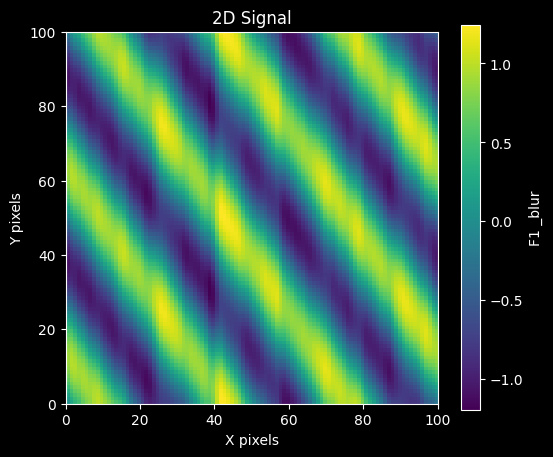

In [374]:
"""2D Case, Work with 1D first """
Nx,Ny = 100,100

x = np.linspace(0, 4*np.pi/2, Nx, endpoint=False)
y = np.linspace(0, 4*np.pi/2, Ny, endpoint=False)



T= 150e-2
w=2*np.pi/T

X,Y = np.meshgrid(x, y)

f1_2 = np.sin(3*X+2*Y)
f2_2 = np.sin(3*(X+1)+2*(Y+1))

f1_noisy = f1_2 + 0.2*np.random.randn(N)
f2_noisy = f2_2 + 0.2*np.random.randn(N)

f1_blur = gaussian_filter(f1_noisy, 1)
f2_blur = gaussian_filter(f2_noisy, 1)

plt.figure(figsize=(6,5))
plt.imshow(f1_blur, origin='lower', cmap='viridis', extent=[0, Nx, 0, Ny])
plt.colorbar(label='F1 _blur')
plt.title('2D Signal')
plt.xlabel('X pixels')
plt.ylabel('Y pixels')
plt.show()


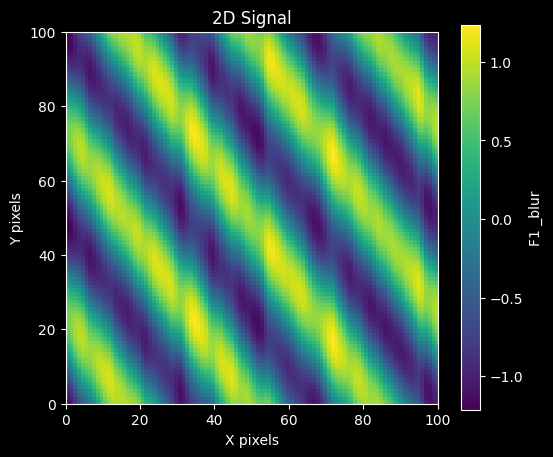

In [375]:
plt.figure(figsize=(6,5))
plt.imshow(f2_blur, origin='lower', cmap='viridis', extent=[0, Nx, 0, Ny])
plt.colorbar(label='F1 _blur')
plt.title('2D Signal')
plt.xlabel('X pixels')
plt.ylabel('Y pixels')
plt.show()

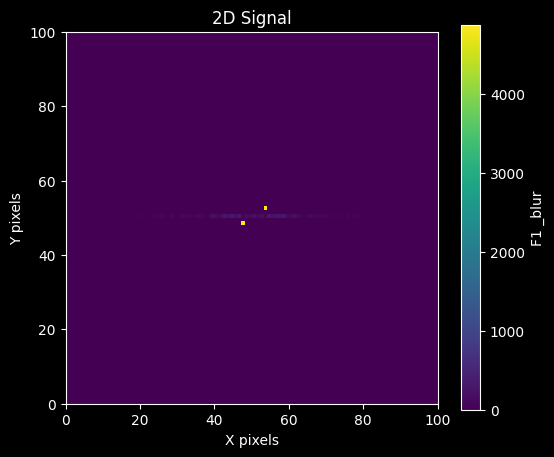

In [376]:
f1_1_fft = np.fft.fft2(f1_blur)
f2_1_fft = np.fft.fft2(f2_blur)

plt.figure(figsize=(6,5))
plt.imshow(np.abs(np.fft.fftshift(f1_1_fft)), origin='lower', cmap='viridis', extent=[0, Nx, 0, Ny])
plt.colorbar(label='F1 _blur')
plt.title('2D Signal')
plt.xlabel('X pixels')
plt.ylabel('Y pixels')
plt.show()

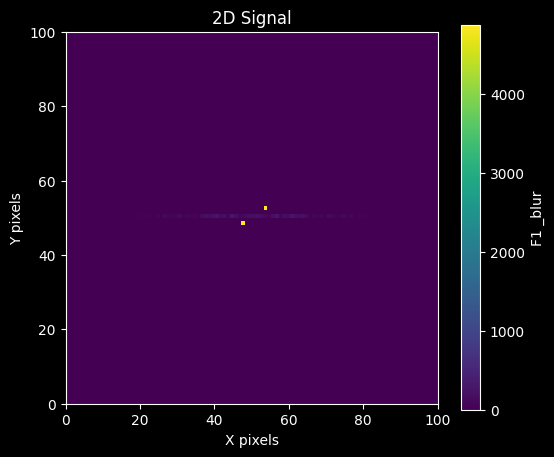

In [377]:
plt.figure(figsize=(6,5))
plt.imshow(np.abs(np.fft.fftshift(f2_1_fft)), origin='lower', cmap='viridis', extent=[0, Nx, 0, Ny])
plt.colorbar(label='F1 _blur')
plt.title('2D Signal')
plt.xlabel('X pixels')
plt.ylabel('Y pixels')
plt.show()

In [378]:
R= f1_noisy*np.conj(f2_noisy)
R /= np.abs(R) + 1e-10

In [379]:
cross_corr_2 = np.fft.ifft2(R)
cross_corr_2_shifted = np.fft.fftshift(cross_corr_2)

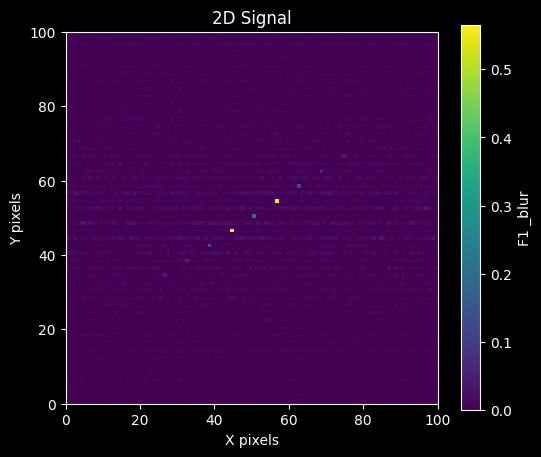

In [380]:
plt.figure(figsize=(6,5))
plt.imshow(np.abs(cross_corr_2_shifted), origin='lower', cmap='viridis', extent=[0, Nx, 0, Ny])
plt.colorbar(label='F1 _blur')
plt.title('2D Signal')
plt.xlabel('X pixels')
plt.ylabel('Y pixels')
plt.show()

In [381]:
peak_index = np.unravel_index(np.argmax(np.abs(cross_corr_2)), cross_corr_2.shape)
center = (Ny//2, Nx//2)
shift_y, shift_x = peak_index[0]-center[0], peak_index[1]-center[1]
print(shift_y, shift_x)

-46 -44


In [382]:
Lx, Ly = 2*np.pi, 2*np.pi  # physical lengths in x and y
real_shift_x = (shift_x / Nx) * Lx
real_shift_y = (shift_y / Ny) * Ly

print("Real-space shift (X,Y):", real_shift_x, real_shift_y)

Real-space shift (X,Y): -2.764601535159018 -2.8902652413026098


In [383]:
"""Now lets us play with lattices"""

'Now lets us play with lattices'

In [432]:
N = 256
x_lat= np.linspace(0,2*np.pi,N)

# Build matrix out of lattice points in 1D

lattice = np.zeros_like(x)
spacing = 2*np.pi/8

# Add lattice points to initialized matrix
for n in range(8):
    lattice += np.exp(-(x-n*spacing)**2/0.05)

In [435]:
lattice += 1.5*np.exp(-(x - 1.3)**2 / 0.03)
lattice += 0.1*np.random.randn(len(lattice))


In [436]:
drift = 0.3
shifted = np.zeros_like(x)
for n in range(8):
    shifted += np.exp(-(x-n*spacing-drift)**2/0.05)


In [438]:
shifted += 1.5*np.exp(-(x - 1.3)**2 / 0.03)
shifted += 0.1*np.random.randn(len(shifted))

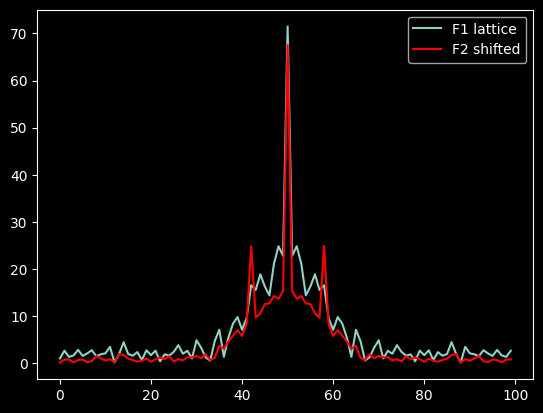

In [461]:
f1_lat = np.fft.fft(lattice)
f2_lat = np.fft.fft(shifted)

plt.plot(np.abs(np.fft.fftshift(f1_lat)), label='F1 lattice')
plt.plot(np.abs(np.fft.fftshift(f2_lat)),color = "red", label='F2 shifted')

plt.legend(loc='upper right')

In [462]:
cross = np.fft.ifft(f1_lat * np.conj(f2_lat))
cross = np.abs(np.fft.fftshift(cross))

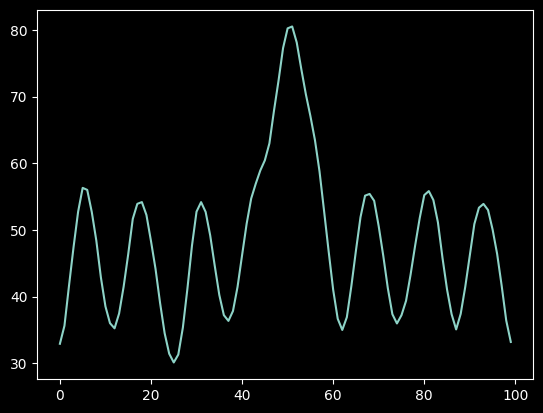

In [463]:
plt.plot(cross)

In [464]:
cross_power = f1_lat * np.conj(f2_lat)
R = cross_power / (np.abs(cross_power) + 1e-10)

phase = np.fft.ifft(R)
phase = np.abs(np.fft.fftshift(phase))

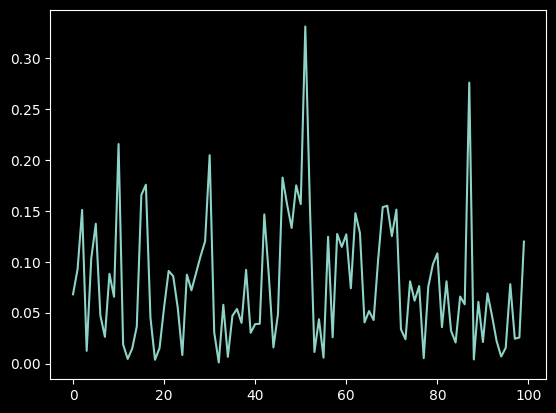

In [465]:
plt.plot(phase)

In [466]:
print(np.argmax(phase))

shift_pixels = np.argmax(phase)-N_1//2

51


In [467]:
dx = (2*np.pi) / N_1

In [468]:
shift_real = shift_pixels * dx

In [469]:
shift_real

np.float64(-1.88986433067511)

In [470]:
"""Now lets visualize a 2D lattice"""

'Now lets visualize a 2D lattice'

In [2]:
import numpy as np
from scipy.ndimage import gaussian_filter

N = 256
x = np.linspace(0, 10, N)
y = np.linspace(0, 10, N)
X, Y = np.meshgrid(x, y)

lattice = np.zeros((N,N))

spacing = 1.5
sigma = 0.15
y_spacing = spacing * np.sqrt(3)/2

for i in np.arange(1,9):
    for j in np.arange(1,9):
        x_offset = (j % 2)* (spacing/2)
        lattice += np.exp(-((X - i*spacing-x_offset)**2 + (Y - j*y_spacing)**2)/(2*sigma**2))

In [3]:
# Gaussian like defect

lattice += 0.5 *np.exp(-((X-3.7)**2+(Y-6.2)**2)/0.05)
lattice += 0.5 * np.exp(-((X - 7.1)**2 + (Y - 2.3)**2) / 0.05)
# lattice -= 1.5*np.exp(-((X-3.7)**2+(Y-6.2)**2)/0.05)

# Add noise
lattice += 0.1*np.random.randn(N,N)

# Add Gaussian blur
lattice = gaussian_filter(lattice, sigma=1)


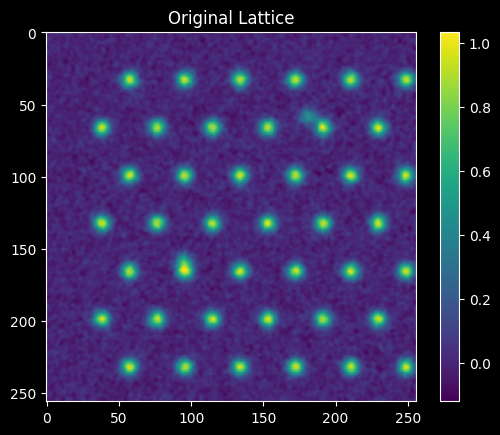

In [4]:
plt.imshow(lattice)
plt.title("Original Lattice")
plt.colorbar()

In [5]:
dx = 10
dy=-10.5

shifted = np.zeros_like(lattice)

for i in np.arange(1,9):
    for j in np.arange(1,9):
        x_offset = (j % 2)* (spacing/2)
        shifted += np.exp(-((X - i*spacing - dx-x_offset)**2 +
                            (Y - j*y_spacing - dy)**2)/(2*sigma**2))

In [6]:
# Add Gaussian deffects
shifted += 0.5 * np.exp(-((X-3.7-dx)**2+(Y-6.2-dy)**2)/0.05)
shifted += 0.5 * np.exp(-((X - 7.1-dx)**2 + (Y - 2.3-dy)**2) / 0.05)
# shifted -= 1.5 * np.exp(-((X-3.7+dx)**2+(Y-6.2+dy)**2)/0.05)

# Add noise
shifted += 0.1*np.random.randn(N,N)

# Add Guassian Blur
shifted = gaussian_filter(shifted, sigma=1)

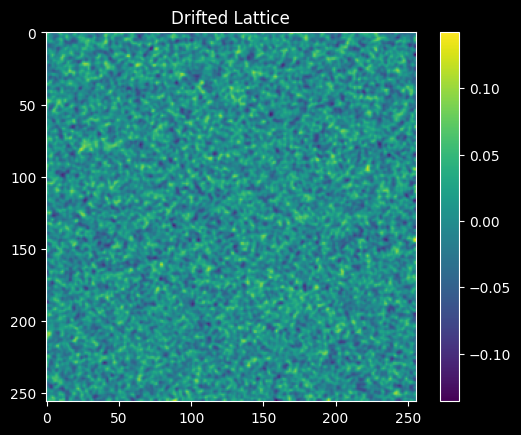

In [7]:
plt.imshow(shifted)
plt.title("Drifted Lattice")
plt.colorbar()

In [8]:
print(f"Original:  min={lattice.min():.2f}, max={lattice.max():.2f}, mean={lattice.mean():.2f}")
print(f"Drifted:   min={shifted.min():.2f}, max={shifted.max():.2f}, mean={shifted.mean():.2f}")

Original:  min=-0.12, max=1.03, mean=0.06
Drifted:   min=-0.14, max=0.14, mean=0.00


In [9]:
# Apply hanning window to get rid of edge discontinuties which blow up phase correaltion
def hanning_2d(N):
    h = np.hanning(N)
    return np.outer(h, h)


window = hanning_2d(N)
F_latt_2d = np.fft.fft2(lattice*window)
F2_latt_2d = np.fft.fft2(shifted*window)

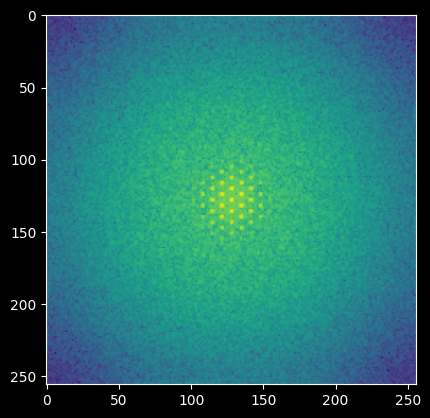

In [10]:
plt.imshow(np.log(np.abs(np.fft.fftshift(F_latt_2d))))

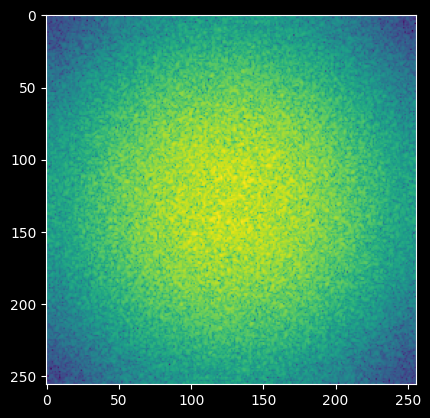

In [11]:
plt.imshow(np.log(np.abs(np.fft.fftshift(F2_latt_2d))))

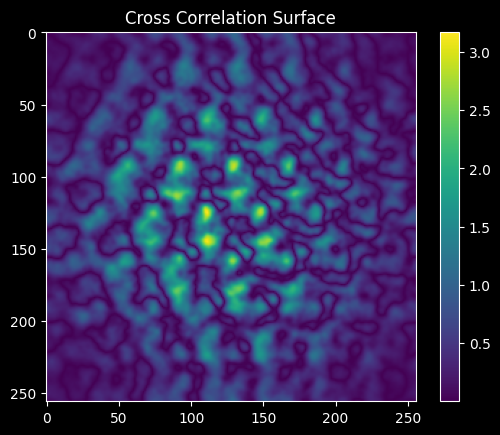

In [12]:
cross = np.fft.ifft2(F_latt_2d * np.conj(F2_latt_2d))
cross = np.abs(np.fft.fftshift(cross))

plt.imshow(cross)
plt.title("Cross Correlation Surface")
plt.colorbar()

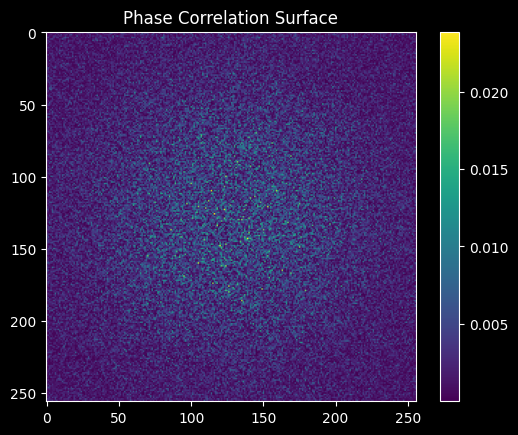

In [13]:
cross_power_2 = F_latt_2d * np.conj(F2_latt_2d)
R_2 = cross_power_2 / (np.abs(cross_power_2) + 1e-10)

phase_2 = np.fft.ifft2(R_2)
phase_2 = np.abs(np.fft.fftshift(phase_2))

plt.imshow(phase_2)
plt.title("Phase Correlation Surface")
plt.colorbar()

In [14]:
# plt.imshow(np.abs(np.fft.fftshift(R_2)))
# plt.colorbar()


In [15]:
pixel_size = x[1] - x[0]
print(f"Pixel size: {pixel_size:.4f}")
print(f"dx in pixels: {dx/pixel_size:.1f}")
print(f"dy in pixels: {dy/pixel_size:.1f}")

Pixel size: 0.0392
dx in pixels: 255.0
dy in pixels: -267.8


In [16]:
peak_2 = np.unravel_index(np.argmax(phase_2), phase_2.shape)

center = np.array(phase_2.shape)//2
shift = np.array(peak_2) - center

print("Measured shift:", shift)
print(peak_2)
print(center)

Measured shift: [ -2 -12]
(np.int64(126), np.int64(116))
[128 128]


In [17]:
dx_measured = shift[1]*(x[1]-x[0])
dy_measured = shift[0]*(y[1]-y[0])

print(dx_measured, dy_measured)

-0.47058823529411764 -0.0784313725490196


In [18]:
print(dx, dy)

10 -10.5


In [19]:
def subpixel_peak(phase, peak):
    r, c = peak
    # fit parabola in x and y around peak
    dr = 0.5 * (phase[r-1, c] - phase[r+1, c]) / (phase[r-1, c] - 2*phase[r, c] + phase[r+1, c])
    dc = 0.5 * (phase[r, c-1] - phase[r, c+1]) / (phase[r, c-1] - 2*phase[r, c] + phase[r, c+1])
    return np.array([r + dr, c + dc])

peak_refined = subpixel_peak(phase_2, peak_2)
shift = peak_refined - center

In [20]:
print(shift)

[ -2.01139665 -11.86451989]


In [21]:
dx_measured = shift[1]*(x[1]-x[0])
dy_measured = shift[0]*(y[1]-y[0])

print(dx_measured, dy_measured)

-0.46527528975826615 -0.07887829986651584


**Try Building your own mixed lattices following this one Template, Also think about how this works!**

In [49]:
import numpy as np

N = 512
x = np.linspace(0, 15, N)
y = np.linspace(0, 15, N)
X, Y = np.meshgrid(x, y)

lattice = np.zeros((N, N))

a = 2.884  # Au nearest-neighbour distance in Angstroms
sigma = 0.3

y_spacing = a * np.sqrt(3) / 2

# Define the three layer offsets for FCC stacking (ABC)
# A layer: no offset
# B layer: offset by (a/2, y_spacing/3) -- sits in first set of hollows
# C layer: offset by (0, 2*y_spacing/3) -- sits in second set of hollows -- makes it FCC not HCP

layers = [
    (0, 0),                        # A layer
    (a/2, y_spacing/3),            # B layer
    (0, 2*y_spacing/3),            # C layer (FCC) — change to (a/2, 0) for HCP
]

for layer_idx, (x_off, y_off) in enumerate(layers):
    # Depth factor — simulate layers getting fainter with depth
    depth_factor = np.exp(-layer_idx * 0.8)

    for i in np.arange(1, 10):
        for j in np.arange(1, 10):
            x_offset = (j % 2) * (a / 2) + x_off
            cx = i * a + x_offset
            cy = j * y_spacing + y_off
            lattice += depth_factor * np.exp(-((X - cx)**2 + (Y - cy)**2) / (2*sigma**2))